In [ ]:
import numpy as np
import pandas as pd

np.random.seed(42)
n_samples = 1000

# Données normales
normal_temp = np.random.normal(-18, 0.5, n_samples)
normal_variation = np.random.normal(0, 0.1, n_samples)  # variation faible
normal_humidity = np.random.normal(85, 2, n_samples)

# Anomalie — clim coupée
anomalie_temp = np.linspace(-18, 5, n_samples) + np.random.normal(0, 0.3, n_samples)
anomalie_variation = np.random.normal(0.5, 0.1, n_samples)  # variation forte
anomalie_humidity = np.random.normal(95, 3, n_samples)  # humidité monte aussi

# Combiner
X_normal = np.column_stack([normal_temp, normal_variation, normal_humidity])
X_anomalie = np.column_stack([anomalie_temp, anomalie_variation, anomalie_humidity])

X = np.vstack([X_normal, X_anomalie])
y = np.concatenate([np.zeros(n_samples), np.ones(n_samples)])

print(f"Dataset: {X.shape[0]} samples, {X.shape[1]} features")
print(f"Features: température, variation, humidité")

Dataset: 2000 samples, 3 features
Features: température, variation, humidité


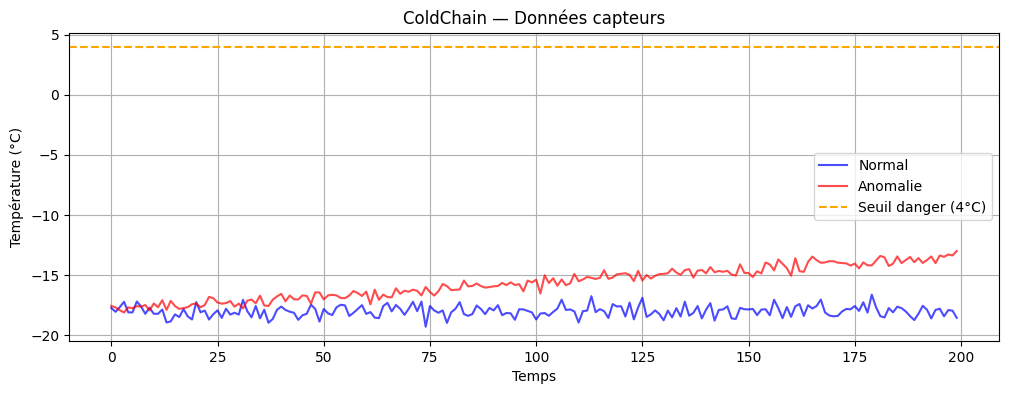

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(normal_temp[:200], label='Normal', color='blue', alpha=0.7)
plt.plot(anomalie_temp[:200], label='Anomalie', color='red', alpha=0.7)
plt.axhline(y=4, color='orange', linestyle='--', label='Seuil danger (4°C)')
plt.xlabel('Temps')
plt.ylabel('Température (°C)')
plt.title('ColdChain — Données capteurs')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(3,)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(
    X_train_scaled, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

loss, accuracy = model.evaluate(X_test_scaled, y_test)
print(f"\nTest accuracy: {accuracy*100:.2f}%")

Epoch 1/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.9906 - loss: 0.4705 - val_accuracy: 0.9969 - val_loss: 0.3027
Epoch 2/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 1.0000 - loss: 0.2118 - val_accuracy: 0.9969 - val_loss: 0.1181
Epoch 3/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 1.0000 - loss: 0.0785 - val_accuracy: 0.9969 - val_loss: 0.0444
Epoch 4/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 0.0291 - val_accuracy: 0.9969 - val_loss: 0.0206
Epoch 5/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0133 - val_accuracy: 0.9969 - val_loss: 0.0124
Epoch 6/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0075 - val_accuracy: 0.9969 - val_loss: 0.0089
Epoch 7/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0048 - val_accuracy: 0.9969 - val_loss: 0.0071
Epoch 8/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0033 - val_accuracy: 0.9969 - val_lo

In [ ]:
# Convertir en TensorFlow Lite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open('coldchain_model.tflite', 'wb') as f:
    f.write(tflite_model)

print(f"Taille modèle original: {model.count_params()} paramètres")
print(f"Taille TFLite: {len(tflite_model)} bytes")

Saved artifact at '/tmp/tmpe0514e6l'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 3), dtype=tf.float32, name='keras_tensor_4')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  134713125260176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134713125260560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134713125259984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134713125273232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134713125271888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134713125260752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134713125259792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134713125272080: TensorSpec(shape=(), dtype=tf.resource, name=None)
Taille modèle original: 801 paramètres
Taille TFLite: 5684 bytes


In [ ]:
# Convertir en tableau C
def convert_to_c_array(tflite_model):
    hex_array = [f"0x{byte:02x}" for byte in tflite_model]
    c_array = ", ".join(hex_array)
    c_code = f"""#ifndef COLDCHAIN_MODEL_H
#define COLDCHAIN_MODEL_H

const unsigned char coldchain_model[] = {{
  {c_array}
}};
const unsigned int coldchain_model_len = {len(tflite_model)};

#endif
"""
    return c_code

c_code = convert_to_c_array(tflite_model)
with open('coldchain_model.h', 'w') as f:
    f.write(c_code)

print("Fichier coldchain_model.h généré")
print(f"Taille: {len(tflite_model)} bytes")

Fichier coldchain_model.h généré
Taille: 5684 bytes


In [ ]:
# Scaler params — 3 features
scaler_code = f"""#ifndef SCALER_PARAMS_H
#define SCALER_PARAMS_H

const float SCALER_MEAN[3] = {{{scaler.mean_[0]:.4f}f, {scaler.mean_[1]:.4f}f, {scaler.mean_[2]:.4f}f}};
const float SCALER_STD[3] = {{{scaler.scale_[0]:.4f}f, {scaler.scale_[1]:.4f}f, {scaler.scale_[2]:.4f}f}};

#endif
"""

with open('scaler_params.h', 'w') as f:
    f.write(scaler_code)

print(f"Mean: {scaler.mean_}")
print(f"Std: {scaler.scale_}")
print("scaler_params.h généré")

Mean: [-12.36082339   0.25200695  89.88292231]
Std: [7.39456245 0.26357444 5.56200948]
scaler_params.h généré


In [ ]:
from google.colab import files
files.download('coldchain_model.h')
files.download('scaler_params.h')
files.download('coldchain_model.tflite')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>